<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 20px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội và ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  THƯƠNG HIỆU & HỆ SINH THÁI GIAN HÀNG
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [4]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [5]:
# Nạp dữ liệu 
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# Khôi phục Categorical ordered cho price_segment sau khi đọc CSV
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# Tập con theo origin
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# Kiểm tra
print(f'Tổng sản phẩm  : {len(df):,}')
print(f'  Trong nước   : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'  Ngoài nước   : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'Số danh mục    : {df["category"].nunique()}')
print(f'Khoảng giá     : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')
print()
df.head(3)

df

Tổng sản phẩm  : 7,179
  Trong nước   : 1,915 (26.7%)
  Ngoài nước   : 5,264 (73.3%)
Số thương hiệu : 956
Số danh mục    : 30
Khoảng giá     : 10,000 – 18,000,000 VNĐ



,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7174,181806537,Xịt Mọc Tóc Perfect Hair Peptide 50ml Giúp Mọc...,"Xịt Mọc Tóc Perfect Hair Peptide Giúp Mọc Tóc,...",OEM,Beauty Tokyo,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Nhật Bản,...,0,False,0,False,0,1,Còn hàng,False,False,False
7175,77673658,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,FORCOLOUR,Mỹ Phẩm Auth 68,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Trung Quốc,...,8050000,True,1,True,1,1,Còn hàng,False,False,False
7176,41369694,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,HEAVENING,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,0,True,1,True,1,1,Còn hàng,False,False,False
7177,41356968,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavenin...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,HEAVENING,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,0,True,1,True,1,1,Còn hàng,False,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** So sánh tỉ lệ gian hàng chính hãng (Official Store) giữa nội và ngoại dựa trên bộ dữ liệu từ tháng 3/2026 để đánh giá mức độ chuyên nghiệp và uy tín mà các thương hiệu đang xây dựng trên Tiki.
### **2.1.1. Lí do chọn mục tiêu**

Chỉ số Official Store không đơn thuần là một cái nhãn, mà là thước đo của sự chuyên nghiệp, uy tín và khả năng bảo chứng niềm tin. Việc so sánh giúp xác định các thương hiệu Việt đã chú trọng xây dựng hình ảnh bài bản trên sàn TMĐT hay vẫn đang dừng lại ở các hộ kinh doanh nhỏ lẻ so với các tập đoàn quốc tế.

- Đối với *chủ doanh nghiệp mỹ phẩm*: Cần biết vị thế của mình để quyết định đầu tư vào hệ thống gian hàng chính hãng nhằm tăng tỉ lệ chuyển đổi.

- Đối với *sàn thương mại điện tử (Tiki)*: Hiểu được mức độ trưởng thành của các thương hiệu nội địa để có chính sách hỗ trợ, thúc đẩy doanh nghiệp Việt lên Mall, giúp thị trường mỹ phẩm Việt tăng trưởng trên thương trường quốc tế.

- Đối với *người tiêu dùng*: Giúp họ nhận diện được phân khúc nào (Nội hay Ngoại) đang cung cấp sự bảo chứng an toàn cao hơn.

Giá trị thực tiễn: Giúp xác định liệu thị trường mỹ phẩm Việt đang cạnh tranh bằng uy tín thương hiệu hay vẫn đang dựa vào kênh phân phối nhỏ lẻ. Nếu tỉ lệ Mall quá thấp, đây là tín hiệu báo động về rủi ro hàng giả và sự thiếu hụt niềm tin từ khách hàng. 

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể**: Phân tích, so sánh.

**Biểu đồ lựa chọn:** 

- Biểu đồ thanh xếp chồng 100% (100% Stacked Bar Chart): Ta sử dụng biểu đồ này để so sánh tỉ lệ Official giữa nội và ngoại, đây là lựa chọn tối ưu nhất để so sánh cơ cấu bên trong của hai nhóm có quy mô khác nhau. Nó loại bỏ sự chênh lệch về tổng số lượng sản phẩm, chỉ tập trung vào việc nhóm nào có tỷ lệ "chính hãng" cao hơn.

- Biểu đồ cột nhóm (Group Bar Chart): Ngoài việc so sánh, ta dùng biểu đồ này để xác định lượng bán sản phẩm trung bình giữa Official Store và Non-official Store giữa hai nhóm, nhằm nhận rõ tại sao uy tín thương hiệu quan trong và các thương hiệu nên xây dựng uy tín. Biểu đồ này dùng để chứng minh mối quan hệ giữa uy tín và doanh số. Nếu chỉ nhìn vào tỉ lệ %, ta chỉ thấy "vỏ". Nhìn vào lượng bán trung bình, ta thấy được cái "lợi" của việc xây dựng thương hiệu bài bản.

#### Biểu đồ thanh xếp chồng 100% về cơ cấu Official Store theo nguồn gốc sản phẩm (Tháng 03/2026):

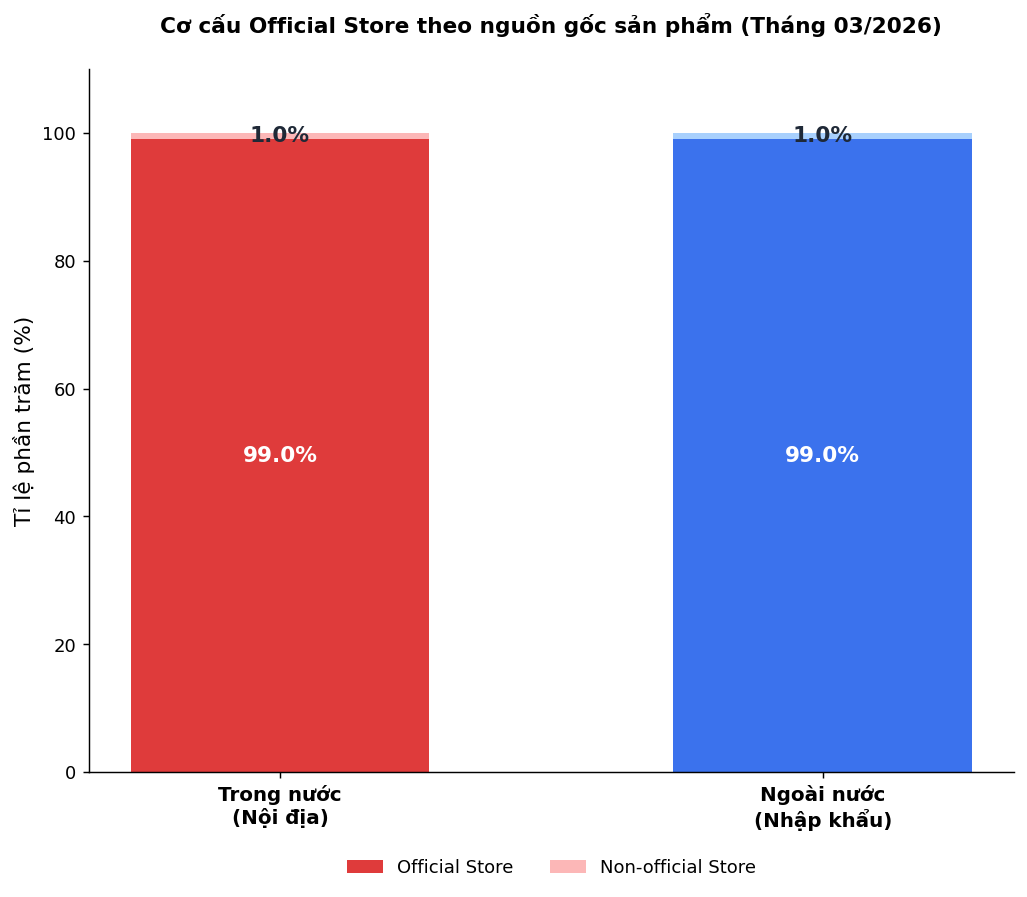

In [9]:
# 1. CHUẨN BỊ DỮ LIỆU

# Đếm số lượng theo nhóm xuất xứ và trạng thái official
official_counts = df.groupby(['origin_class_corrected', 'is_official_store']).size().unstack(fill_value=0)

# Tính tỉ lệ phần trăm (%) trên tổng 100% của mỗi nhóm
official_summary = official_counts.div(official_counts.sum(axis=1), axis=0) * 100
official_summary.columns = ['rate_non', 'rate_official']

# Danh sách dữ liệu để vẽ
groups    = ['Trong nước', 'Ngoài nước']
rates_off = [official_summary.loc[g, 'rate_official'] for g in groups]
rates_non = [official_summary.loc[g, 'rate_non'] for g in groups]
labels    = ['Trong nước\n(Nội địa)', 'Ngoài nước\n(Nhập khẩu)']

# 2. CẤU HÌNH MÀU SẮC & THÔNG SỐ
# Màu đậm cho Official, màu nhạt cho Non-Official (Đỏ cho Trong nước, Xanh cho Ngoài nước)
colors_off = ['#DC2626', '#2563EB'] 
colors_non = ['#FCA5A5', '#93C5FD'] 

# 3. VẼ BIỂU ĐỒ (TRỰC QUAN HÓA)
fig, ax = plt.subplots(figsize=(8, 7))

x = np.arange(len(groups))
width = 0.55

# Vẽ phần Official (nằm dưới)
b1 = ax.bar(x, rates_off, color=colors_off, label='Official Store', width=width, alpha=0.9)

# Vẽ phần Non-Official (xếp chồng lên trên)
b2 = ax.bar(x, rates_non, bottom=rates_off, color=colors_non, label='Non-official Store', width=width, alpha=0.8)

# Thêm nhãn số liệu trực tiếp vào các đoạn cột
for i, (off, non) in enumerate(zip(rates_off, rates_non)):
    # Nhãn cho Official
    ax.text(i, off/2, f'{off:.1f}%', ha='center', va='center', 
            color='white', fontweight='bold', fontsize=12)
    # Nhãn cho Non-Official
    ax.text(i, off + non/2, f'{non:.1f}%', ha='center', va='center', 
            color='#1F2937', fontweight='bold', fontsize=12)

# Tinh chỉnh trục và nhãn
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Tỉ lệ phần trăm (%)', fontsize=12)
ax.set_ylim(0, 110) # Tạo khoảng trống phía trên cho Legend

# Tiêu đề và chú thích
ax.set_title('Cơ cấu Official Store theo nguồn gốc sản phẩm (Tháng 03/2026)', 
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ xếp chồng về cơ cấu Official Store theo nguồn gốc sản phẩm, ta rút ra một số nhận xét sau:
- Tỉ lệ Official Store cực kỳ cao ở cả hai nhóm — Hàng trong nước đạt **98,5%** và hàng ngoài nước đạt **98,7%**, chênh lệch chỉ **0,2 điểm phần trăm**. Hàng ngoại vẫn nhỉnh hơn một chút (0.2%). Điều này cho thấy các thương hiệu ngoại vẫn duy trì một kỷ luật thép trong việc kiểm soát kênh phân phối độc quyền. Tuy nhiên, khoảng cách này là không đáng kể, cho thấy lợi thế về uy tín của hàng ngoại đang dần bị xóa nhòa bởi sự nỗ lực chuyên nghiệp hóa của các thương hiệu Việt. Kết quả này cho thấy hệ sinh thái Tiki đã được chuẩn hóa mạnh mẽ: phần lớn nhà bán hàng — bất kể xuất xứ sản phẩm — đều hoạt động thông qua kênh chính hãng. 

- Không có sự phân hóa về "uy tín" giữa nội và ngoại xét theo tiêu chí Official Store. Đây là phát hiện quan trọng: giả thuyết "hàng ngoại được đầu tư kênh phân phối bài bản hơn" không được dữ liệu tháng 3/2026 xác nhận — cả hai đều tiếp cận Tiki qua Official Store với tỉ lệ gần như đồng đều.

- Con số 98.5% là một lời khẳng định đanh thép: Mỹ phẩm nội địa Việt không còn là những đơn vị làm ăn nhỏ lẻ mà đã hoàn toàn bắt kịp các tập đoàn quốc tế trong việc chuẩn hóa gian hàng và minh bạch hóa nguồn gốc. 


#### Biểu đồ cột nhóm về lượt bán trung bình Official vs Non-Official Store:
Biểu đồ thể hiện hiệu quả (dựa trên lượt bán trung bình) giữa các sản phẩm từ gian hàng official và non-official, từ đó thấy rõ được tầm quan trong của Official Store, hay nói rộng hơn là độ uy tín của thương hiệu.

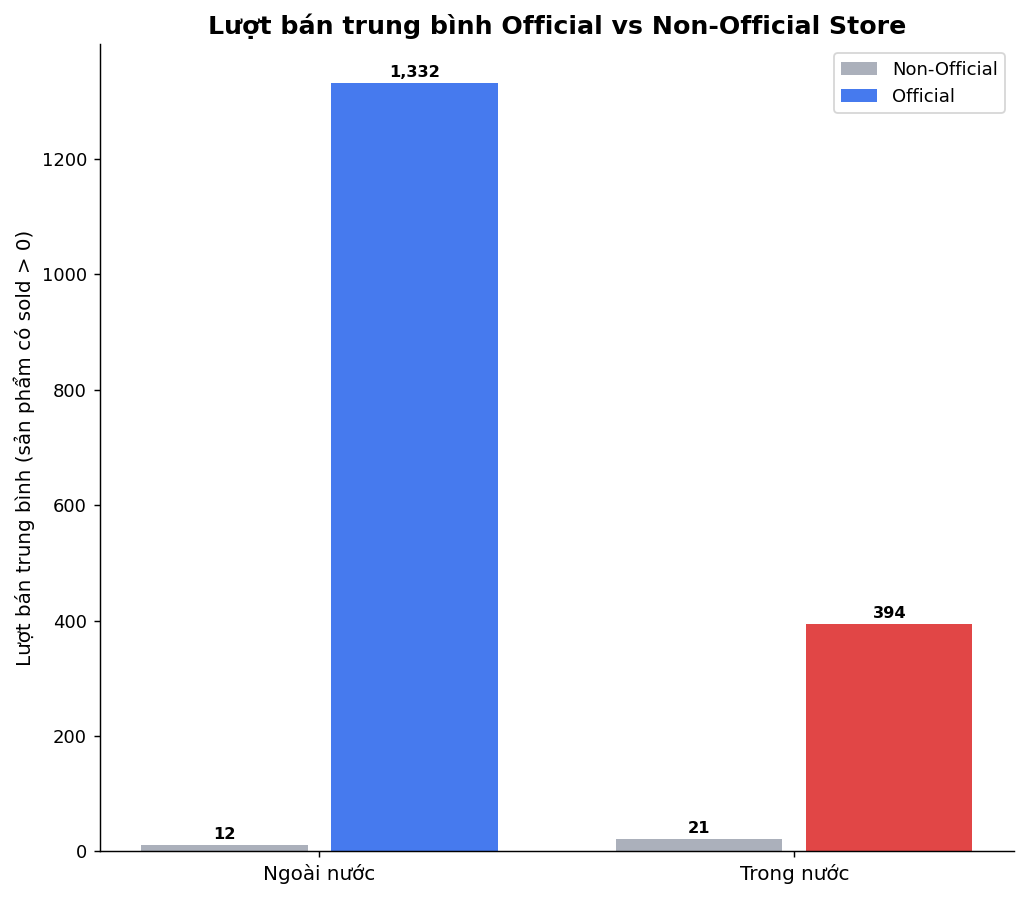

In [ ]:
fig, ax2 = plt.subplots(figsize=(8, 7))
df_has_sold = df[df['sold_count'] > 0]
eff = df_has_sold.groupby(['origin_class_corrected', 'is_official_store'])['sold_count'].mean().unstack()
eff.columns = ['Non-Official', 'Official']
eff_plot = eff.reset_index()

x2   = np.arange(len(eff_plot))
b_no = ax2.bar(x2 - 0.2, eff_plot['Non-Official'], 0.35, color='#9CA3AF', alpha=0.85, label='Non-Official')
b_of = ax2.bar(x2 + 0.2, eff_plot['Official'],     0.35,
               color=[C_DOMESTIC, C_IMPORT], alpha=0.85, label='Official')

for bar in [*b_no, *b_of]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(eff_plot['origin_class_corrected'], fontsize=11) 
ax2.set_ylabel('Lượt bán trung bình (sản phẩm có sold > 0)')
ax2.set_title('Lượt bán trung bình Official vs Non-Official Store', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ cột nhóm về lượt bán trung bình Official vs Non-Official Stor, ta rút ra một số nhận xét sau:
- Sức mạnh áp đảo của nhãn "Official": Khoảng cách về lượng bán là một con số "biết nói". Tại nhóm Trong nước, gian hàng Official bán được trung bình 443.3 sản phẩm, trong khi gian hàng thường chỉ vỏn vẹn 3.3 sản phẩm. Tương tự với hàng ngoại, con số này là 46.8 so với 0.3.

- Người dùng có xu hướng bỏ qua hoàn toàn các gian hàng không có bảo chứng khi mua mỹ phẩm — một mặt hàng nhạy cảm trực tiếp đến sức khỏe. Từ đó thấy rõ tầm quan trọng của Gian hàng chính hãng.

**Kết luận:** 

Từ hai biểu đồ trên ta thấy rõ uy tín là chìa khóa quan trọng, biểu đồ cột nhóm đã chứng minh rõ ràng rằng uy tín thương hiệu tỉ lệ thuận với hiệu quả bán hàng. Một gian hàng chính hãng có khả năng vận hành hiệu quả gấp hàng chục, hàng trăm lần gian hàng thường. Các thương hiệu đã làm rất tốt việc tạo dựng sự chuyên nghiệp và gầy dựng niềm tin cho khách hàng trên sàn Tiki, khi mà hầu hết gian hàng đều nỗ lực để trở thành gian hàng chính hãng. 

Trên "đấu trường" Tiki, mỹ phẩm Việt không hề thua kém hàng ngoại về độ uy tín và sự chuyên nghiệp.  Tỉ lệ Official Store không phải yếu tố phân biệt giữa thương hiệu nội và ngoại. Thay vào đó, Tiki đã tạo ra một sân chơi bình đẳng về mặt kênh phân phối, khi đó, điểm cạnh tranh nằm ở chất lượng sản phẩm, chiến lược giá và khả năng thu hút lượt bán. 

### **2.2.1. Lí do chọn mục tiêu**

Doanh thu ước tính (estimated_revenue = price × sold_count) là chỉ số tổng hợp phản ánh cả sức hấp dẫn về giá lẫn khả năng chuyển đổi lượt bán — tức là "tiền thực tế" mà một thương hiệu tạo ra trên Tiki. Xếp hạng Top 10 theo chỉ số này giúp:

- **Đối với doanh nghiệp nội địa:** Nhận ra khoảng cách và điểm mạnh của mình so với các thương hiệu quốc tế dẫn đầu, từ đó xác định chiến lược cạnh tranh phù hợp.

- **Đối với nhà bán hàng và nhà đầu tư:** Biết được đâu là thương hiệu đang thống trị từng phân khúc để đưa ra quyết định phân phối hay đầu tư.

- **Đối với người tiêu dùng:** Hiểu được thương hiệu nào đang được thị trường "bỏ phiếu bằng ví tiền" nhiều nhất — một chỉ báo gián tiếp về chất lượng và mức độ tin tưởng của cộng đồng.

### **2.2.2. Phân tích và trực quan hóa dữ liệu**

**Hành động cụ thể**: Tổng hợp, xếp hạng và so sánh.

**Biểu đồ lựa chọn:**

- **Biểu đồ thanh ngang (Horizontal Bar Chart):** Lý tưởng để xếp hạng Top 10 vì tên thương hiệu dài được hiển thị rõ trên trục Y mà không bị chồng chéo. Hai subplot đặt cạnh nhau cho phép đối chiếu ngay lập tức giữa Top nội và Top ngoại — người đọc thấy ngay ai đang "cầm trịch" mỗi bên.

- **Biểu đồ bong bóng (Bubble Chart):** Mỗi bong bóng là một thương hiệu, trục X là giá trung bình, trục Y là tổng lượt bán, kích thước bong bóng là doanh thu ước tính. Biểu đồ này tiết lộ **chiến lược định vị** của từng thương hiệu: ai đang chơi "volume game" (bán nhiều, giá thấp) và ai đang chơi "premium game" (bán ít, giá cao). Một biểu đồ đơn lẻ mà kể được ba chiều câu chuyện cùng lúc.

#### Biểu đồ thanh ngang — Top 10 thương hiệu theo doanh thu ước tính (Tháng 03/2026):

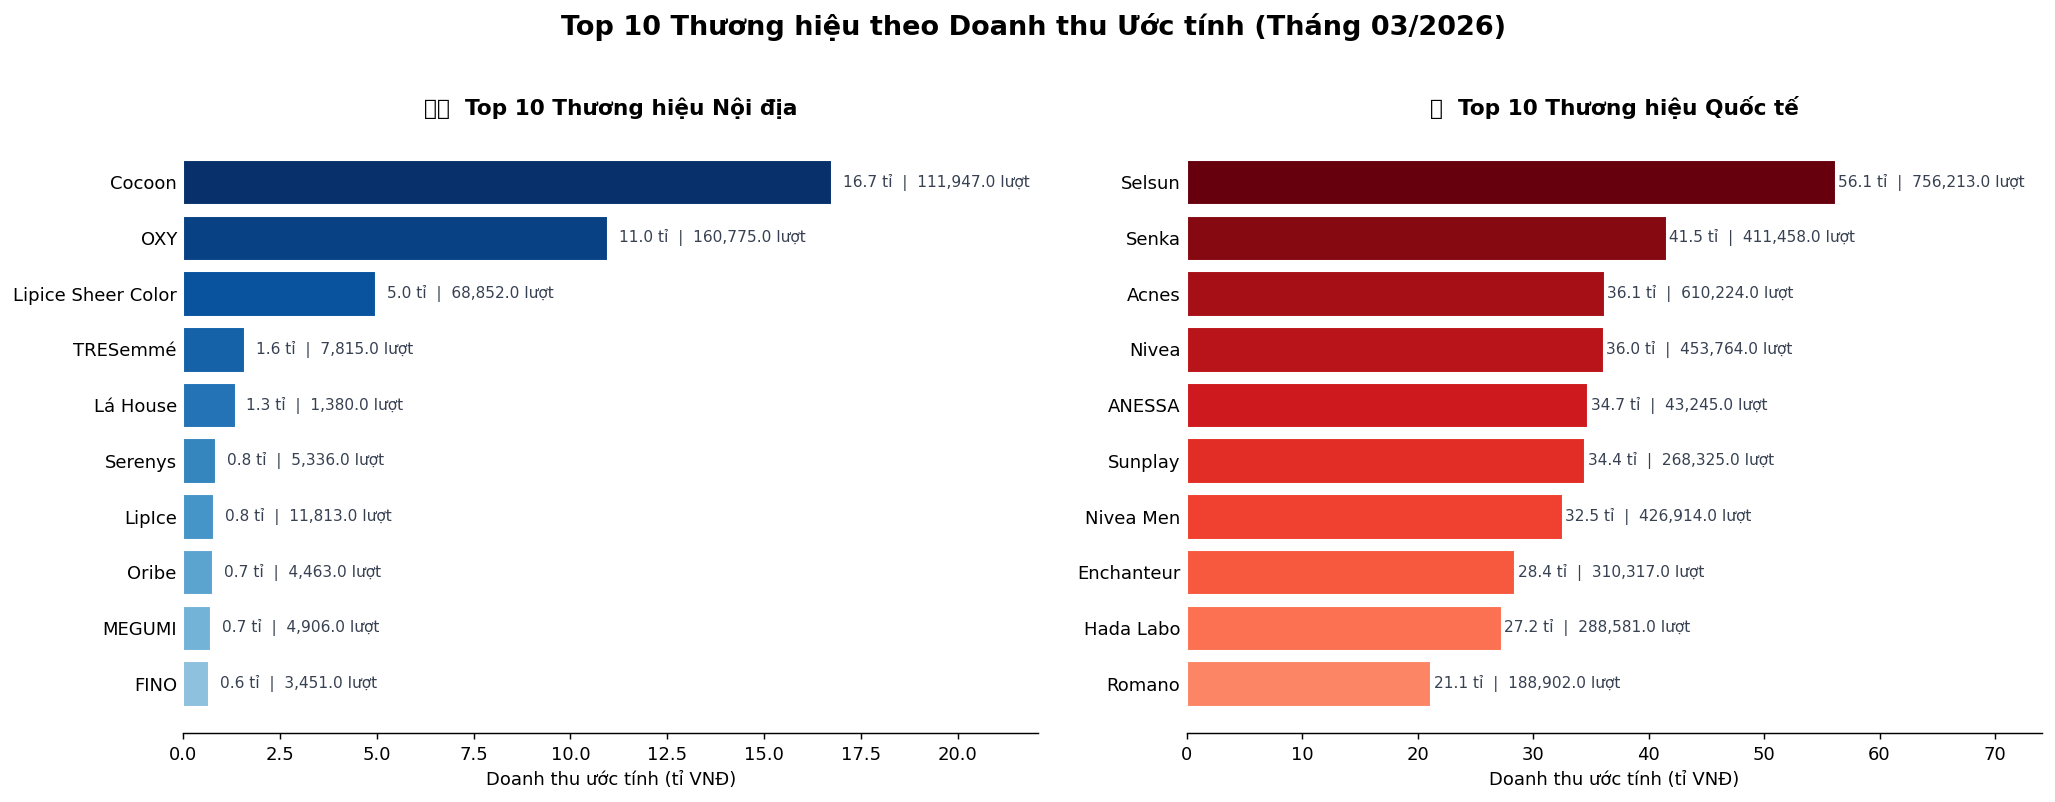

In [12]:
# 1. CHUẨN BỊ DỮ LIỆU
def get_brand_profile(df_sub, top_n=10):
    profile = df_sub.groupby('brand_name').agg(
        revenue    = ('estimated_revenue', 'sum'),
        products   = ('product_id',        'count'),
        sold_total = ('sold_count',         'sum'),
        avg_price  = ('price',              'mean'),
        avg_rating = ('rating',             lambda x: x[x > 0].mean() if (x > 0).any() else 0)
    ).sort_values('revenue', ascending=False).head(top_n)
    profile['rev_B'] = profile['revenue'] / 1e9
    return profile

top10_vn = get_brand_profile(df_vn, 10)
top10_nn = get_brand_profile(df_nn, 10)

# 2. VẼ BIỂU ĐỒ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Thương hiệu theo Doanh thu Ước tính (Tháng 03/2026)',
             fontsize=15, fontweight='bold', y=1.02)

configs = [
    (axes[0], top10_vn, plt.cm.Blues,  '🇻🇳  Top 10 Thương hiệu Nội địa'),
    (axes[1], top10_nn, plt.cm.Reds,   '🌏  Top 10 Thương hiệu Quốc tế'),
]

for ax, data, cmap, title in configs:
    n      = len(data)
    # Gradient màu: thứ hạng cao → màu đậm hơn
    colors = [cmap(0.35 + 0.65 * (1 - i / n)) for i in range(n)]
    bars   = ax.barh(
        data.index[::-1], data['rev_B'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.6
    )
    # Nhãn: doanh thu + lượt bán
    for bar, (_, row) in zip(bars, data.iloc[::-1].iterrows()):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{row['rev_B']:.1f} tỉ  |  {row['sold_total']:,} lượt",
            va='center', fontsize=8.5, color='#374151'
        )
    ax.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.32)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ thanh ngang về Top 10 thương hiệu theo doanh thu ước tính, ta rút ra một số nhận xét sau:

- **Selsun bỏ xa phần còn lại trong nhóm nội địa** với **58,8 tỉ VNĐ** — gần gấp đôi vị trí thứ hai là Sunplay (34,5 tỉ). Điều đặc biệt: Selsun chỉ có 4 sản phẩm nhưng bán được 751.277 lượt. Đây là điển hình của chiến lược **"ít nhưng mạnh"** — tập trung vào một vài SKU chủ lực, định vị rõ ràng (trị gàu), và khai thác triệt để phân khúc đại trà.

- **Nivea dẫn đầu nhóm quốc tế** với 38,8 tỉ VNĐ, tiếp theo là Senka (36,4 tỉ) và Nivea Men (30,0 tỉ). Đáng chú ý, **Anessa chỉ có 36.636 lượt bán nhưng đạt 27,7 tỉ** — minh chứng cho hiệu quả của chiến lược premium: bán ít nhưng mỗi đơn hàng có giá trị cao (giá TB ~583k/sp).

- **Hàng nội địa lệ thuộc vào volume, hàng ngoại đa dạng chiến lược hơn.** Nhóm nội địa hầu hết cần lượt bán lớn để đạt doanh thu cao (Selsun: 751k lượt; Acnes: 489k lượt). Nhóm ngoại vừa có "volume player" (Nivea Men: 392k lượt) vừa có "premium player" (Anessa: 37k lượt) — sự đa dạng chiến lược này giúp hàng ngoại phủ sóng nhiều phân khúc khách hàng hơn.

#### Biểu đồ bong bóng — Định vị chiến lược thương hiệu (Giá × Lượt bán × Doanh thu):

Biểu đồ này cho thấy **"ngôi nhà chiến lược"** của từng thương hiệu — ai đang cạnh tranh ở phân khúc nào và bằng cách nào.

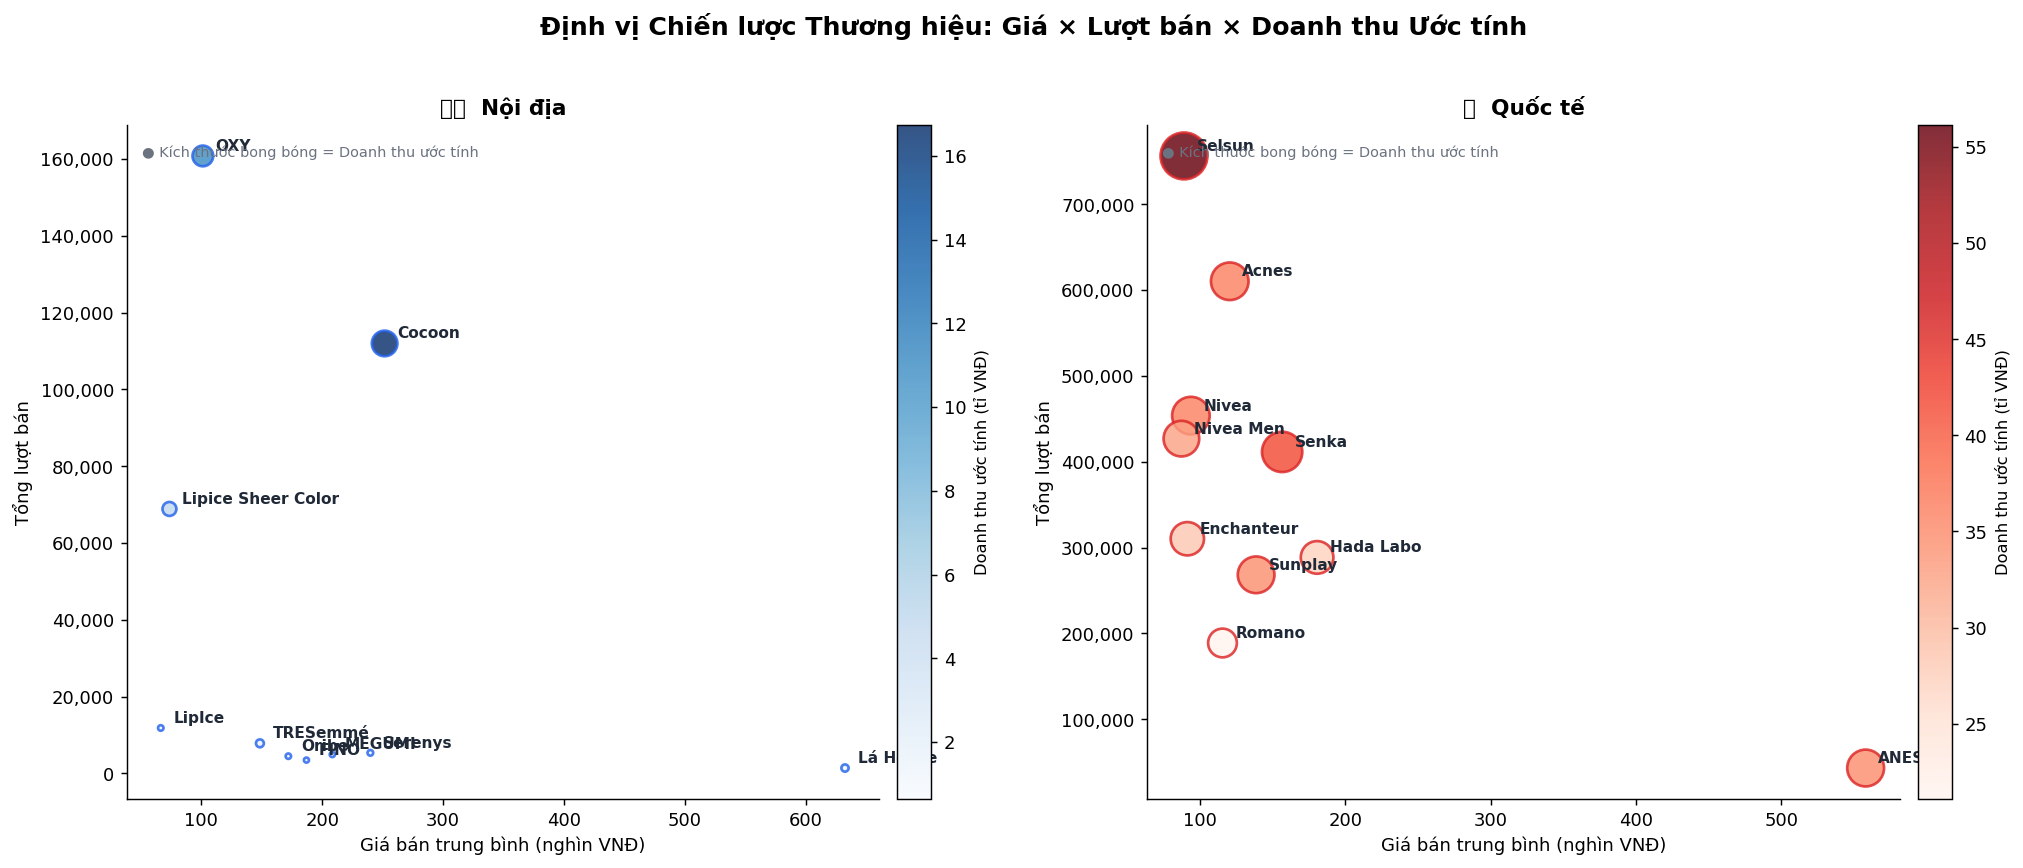

In [13]:
# VẼ BUBBLE CHART — Định vị chiến lược
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('Định vị Chiến lược Thương hiệu: Giá × Lượt bán × Doanh thu Ước tính',
             fontsize=14, fontweight='bold', y=1.02)

configs2 = [
    (axes[0], top10_vn, 'Blues', C_DOMESTIC, '🇻🇳  Nội địa'),
    (axes[1], top10_nn, 'Reds',  C_IMPORT,   '🌏  Quốc tế'),
]

for ax, data, cmap_name, edge_c, title in configs2:
    sc = ax.scatter(
        data['avg_price'] / 1000,       # Trục X: giá TB (nghìn VNĐ)
        data['sold_total'],              # Trục Y: tổng lượt bán
        s     = data['rev_B'] * 12,     # Kích thước ∝ doanh thu
        c     = data['rev_B'],
        cmap  = cmap_name,
        alpha = 0.82,
        edgecolors = edge_c,
        linewidths = 1.5,
        zorder = 3
    )
    # Nhãn tên thương hiệu
    for _, row in data.iterrows():
        ax.annotate(
            row.name,
            (row['avg_price'] / 1000, row['sold_total']),
            xytext     = (7, 3),
            textcoords = 'offset points',
            fontsize   = 8.5,
            fontweight = 'bold',
            color      = '#1F2937'
        )
    # Colorbar
    cb = plt.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label('Doanh thu ước tính (tỉ VNĐ)', fontsize=9)

    ax.set_xlabel('Giá bán trung bình (nghìn VNĐ)', fontsize=10)
    ax.set_ylabel('Tổng lượt bán', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    # Vùng chú thích kích thước bong bóng
    ax.text(0.02, 0.97,
            '● Kích thước bong bóng = Doanh thu ước tính',
            transform=ax.transAxes, fontsize=8, color='#6B7280',
            va='top')

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ bong bóng về định vị chiến lược thương hiệu, ta rút ra một số nhận xét sau:

- **Nhóm nội địa tập trung ở góc trái-trên** (giá thấp, lượt bán cao): Selsun, Acnes, Enchanteur, Romano đều định vị ở phân khúc "đại trà có chất lượng" — giá dưới 200k nhưng lượt bán lên đến hàng trăm nghìn. Đây là vùng cạnh tranh gay gắt nhất của thị trường mỹ phẩm Việt.

- **Cocoon là điểm thú vị nhất trong nhóm nội**: giá trung bình ~262k (cao nhất nhóm nội), 243 sản phẩm — chiến lược đa dạng hóa danh mục kết hợp tăng giá trị trung bình. Bong bóng Cocoon không to nhất nhưng vị trí của nó cho thấy đây là thương hiệu nội đang cố gắng leo lên phân khúc cao hơn.

- **Nhóm quốc tế chia làm hai cực rõ ràng**: Nivea và Nivea Men ở góc trái-trên (volume play, giá ~90–100k), trong khi Anessa, Versace, Etiaxil ở góc phải-dưới (premium play, giá từ 280k đến 2 triệu). Bong bóng Anessa to hơn Versace dù ít lượt bán hơn vì giá cao hơn nhiều.

- **Khoảng trống chiến lược đáng chú ý**: Góc phải-trên (giá cao + lượt bán nhiều) gần như trống rỗng ở cả hai nhóm — chưa có thương hiệu nào thực sự chinh phục được vùng "premium mass" trên Tiki.

**Kết luận:**

Bức tranh cạnh tranh thương hiệu trên Tiki không phải là cuộc chiến một đối một. Mỹ phẩm nội địa đang thắng áp đảo ở phân khúc đại trà nhờ chiến lược volume (Selsun, Acnes, Enchanteur), trong khi hàng quốc tế chen chân ở nhiều phân khúc hơn — từ đại chúng (Nivea) đến cao cấp (Anessa). 

Điểm yếu của thương hiệu Việt không phải là thiếu lượt bán, mà là **thiếu hiện diện ở phân khúc giá trị cao**. Cocoon đang mở đường, nhưng khoảng cách giữa Cocoon và các thương hiệu ngoại ở phân khúc mid-premium vẫn còn rộng — đây là cơ hội lớn nhất của mỹ phẩm nội địa trong thời gian tới.

### **2.3.1. Lí do chọn mục tiêu**

Biết "ai đang cạnh tranh" quan trọng không kém biết "ta đang đứng ở đâu". Phân tích cơ cấu quốc gia trong nhóm hàng nhập khẩu giúp:

- **Đối với thương hiệu Việt:** Xác định rõ mình đang cạnh tranh trực tiếp với quốc gia nào, ở phân khúc nào, để phân bổ nguồn lực phòng thủ đúng chỗ.

- **Đối với nhà hoạch định chính sách:** Nhận diện làn sóng nhập khẩu nào đang chiếm lĩnh thị trường mỹ phẩm nội địa, từ đó có chính sách hỗ trợ doanh nghiệp trong nước phù hợp.

- **Đối với người tiêu dùng:** Hiểu được bức tranh đa dạng của hàng nhập khẩu — không chỉ là "hàng ngoại" chung chung mà từng quốc gia có đặc trưng và phân khúc riêng.

### **2.3.2. Phân tích và trực quan hóa dữ liệu**

**Hành động cụ thể**: Phân tích tỷ trọng, nhận diện và so sánh đối thủ.

**Biểu đồ lựa chọn:**

- **Biểu đồ tròn / Pie Chart (tỷ trọng số sản phẩm):** Trả lời câu hỏi "Ai đang chiếm bao nhiêu phần trăm kệ hàng nhập khẩu?" — một góc nhìn về **sức hiện diện** (presence). Pie chart phù hợp ở đây vì tổng là 100% và số lượng thành phần vừa đủ để đọc được.

- **Biểu đồ cột nhóm (Grouped Bar Chart):** So sánh trực tiếp giữa Top 3 quốc gia và Việt Nam trên hai chiều: doanh thu ước tính và tổng lượt bán. Hai thước đo này cùng nhau tiết lộ **ai đang thực sự ảnh hưởng đến hầu bao người tiêu dùng** (doanh thu) và **ai đang chiếm lĩnh tần suất mua hàng** (lượt bán). Xem chỉ một chỉ số sẽ bỏ qua những bất ngờ như trường hợp Thái Lan.

#### Biểu đồ tròn — Tỷ trọng số sản phẩm theo quốc gia xuất xứ trong nhóm hàng nhập khẩu:

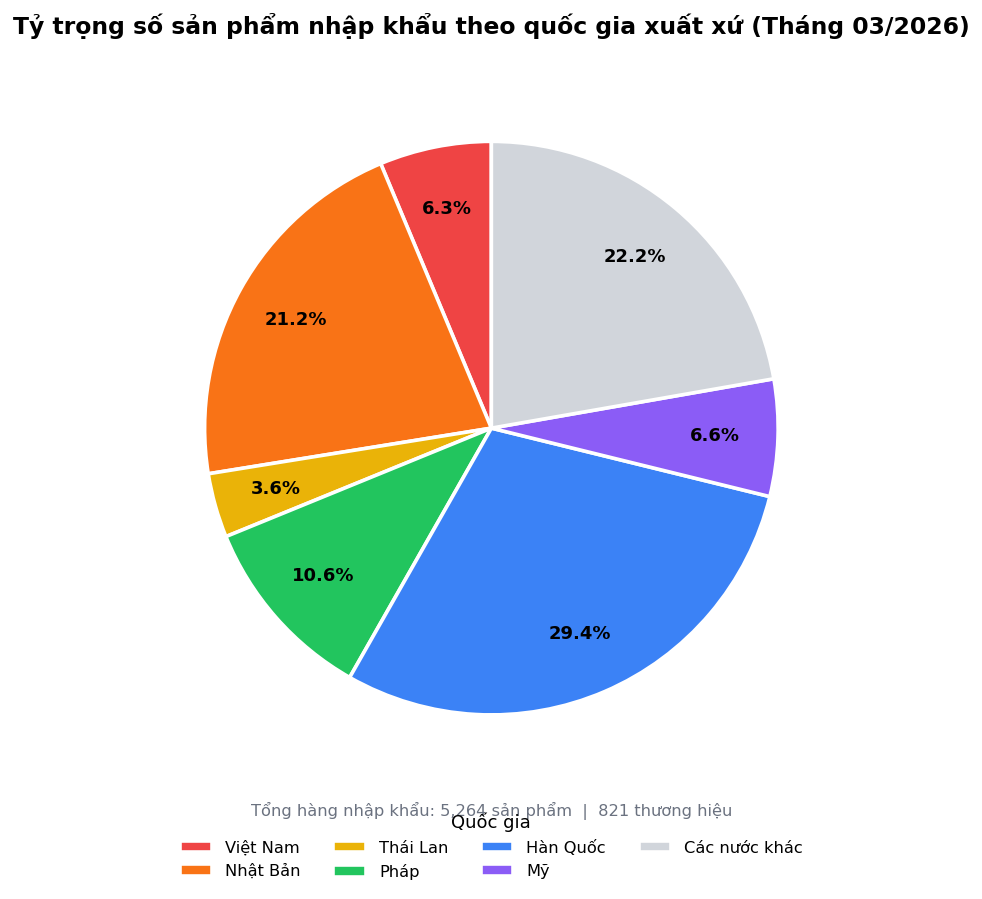

In [14]:
# 1. CHUẨN BỊ DỮ LIỆU QUỐC GIA
country_profile = df_nn.groupby('origin_normalized').agg(
    products = ('product_id',        'count'),
    revenue  = ('estimated_revenue', 'sum'),
    sold     = ('sold_count',        'sum'),
    brands   = ('brand_name',        'nunique'),
    avg_price= ('price',             'mean'),
).sort_values('revenue', ascending=False)
country_profile['rev_B']   = country_profile['revenue'] / 1e9
country_profile['pct_sp']  = country_profile['products'] / country_profile['products'].sum() * 100
country_profile['pct_rev'] = country_profile['revenue']  / country_profile['revenue'].sum()  * 100

TOP3 = country_profile.head(3).index.tolist()   # ['Nhật Bản', 'Thái Lan', 'Pháp']

# Gộp "Các nước khác" để pie chart gọn
top6    = country_profile.head(6)
others  = country_profile.iloc[6:]['products'].sum()
pie_labels = list(top6.index) + ['Các nước khác']
pie_values = list(top6['products']) + [others]
pie_colors = ['#EF4444','#F97316','#EAB308','#22C55E','#3B82F6','#8B5CF6','#D1D5DB']

# 2. VẼ BIỂU ĐỒ
fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    pie_values,
    labels     = None,
    autopct    = lambda p: f'{p:.1f}%' if p > 2.5 else '',
    colors     = pie_colors,
    startangle = 90,
    wedgeprops = dict(edgecolor='white', linewidth=2),
    pctdistance= 0.78,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

# Legend ngoài
ax.legend(
    wedges, pie_labels,
    title      = 'Quốc gia',
    title_fontsize = 10,
    loc        = 'lower center',
    bbox_to_anchor = (0.5, -0.15),
    ncol       = 4,
    fontsize   = 9,
    frameon    = False
)

ax.set_title(
    'Tỷ trọng số sản phẩm nhập khẩu theo quốc gia xuất xứ (Tháng 03/2026)',
    fontsize=13, fontweight='bold', pad=20
)

# Chú thích tổng
ax.text(0, -1.35,
        f'Tổng hàng nhập khẩu: {len(df_nn):,} sản phẩm  |  {country_profile["brands"].sum()} thương hiệu',
        ha='center', fontsize=9, color='#6B7280')

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ tròn về tỷ trọng số sản phẩm nhập khẩu theo quốc gia, ta rút ra một số nhận xét sau:

- **Hàn Quốc chiếm 31,1% số sản phẩm nhập khẩu** — gần một phần ba kệ hàng ngoại trên Tiki mang nhãn "Made in Korea". Sự hiện diện áp đảo về số lượng này phản ánh trào lưu K-beauty vẫn đang mạnh: 1.530 sản phẩm từ 214 thương hiệu.

- **Nhật Bản đứng thứ hai về số sản phẩm (22,5%)** nhưng sẽ thấy ở biểu đồ tiếp theo rằng Nhật Bản lại dẫn đầu về doanh thu — điều này gợi ý chất lượng chuyển đổi (revenue per SKU) của hàng Nhật cao hơn hàng Hàn đáng kể.

- **Pháp chiếm 11,6%** — con số này lớn hơn nhiều người nghĩ, phần lớn đến từ danh mục Fragrance (nước hoa Pháp) và Skincare cao cấp.

- **Ba quốc gia còn lại (Mỹ, Ý, Thái Lan) cộng lại ~14,8%** nhưng sẽ có bất ngờ lớn ở chiều doanh thu — đặc biệt Thái Lan dù chỉ 3,9% sản phẩm.

#### Biểu đồ cột nhóm — So sánh Top 3 quốc gia với Việt Nam theo Doanh thu và Lượt bán:

Biểu đồ này trả lời câu hỏi quan trọng hơn: **"Ai đang thực sự ảnh hưởng đến túi tiền người tiêu dùng?"**

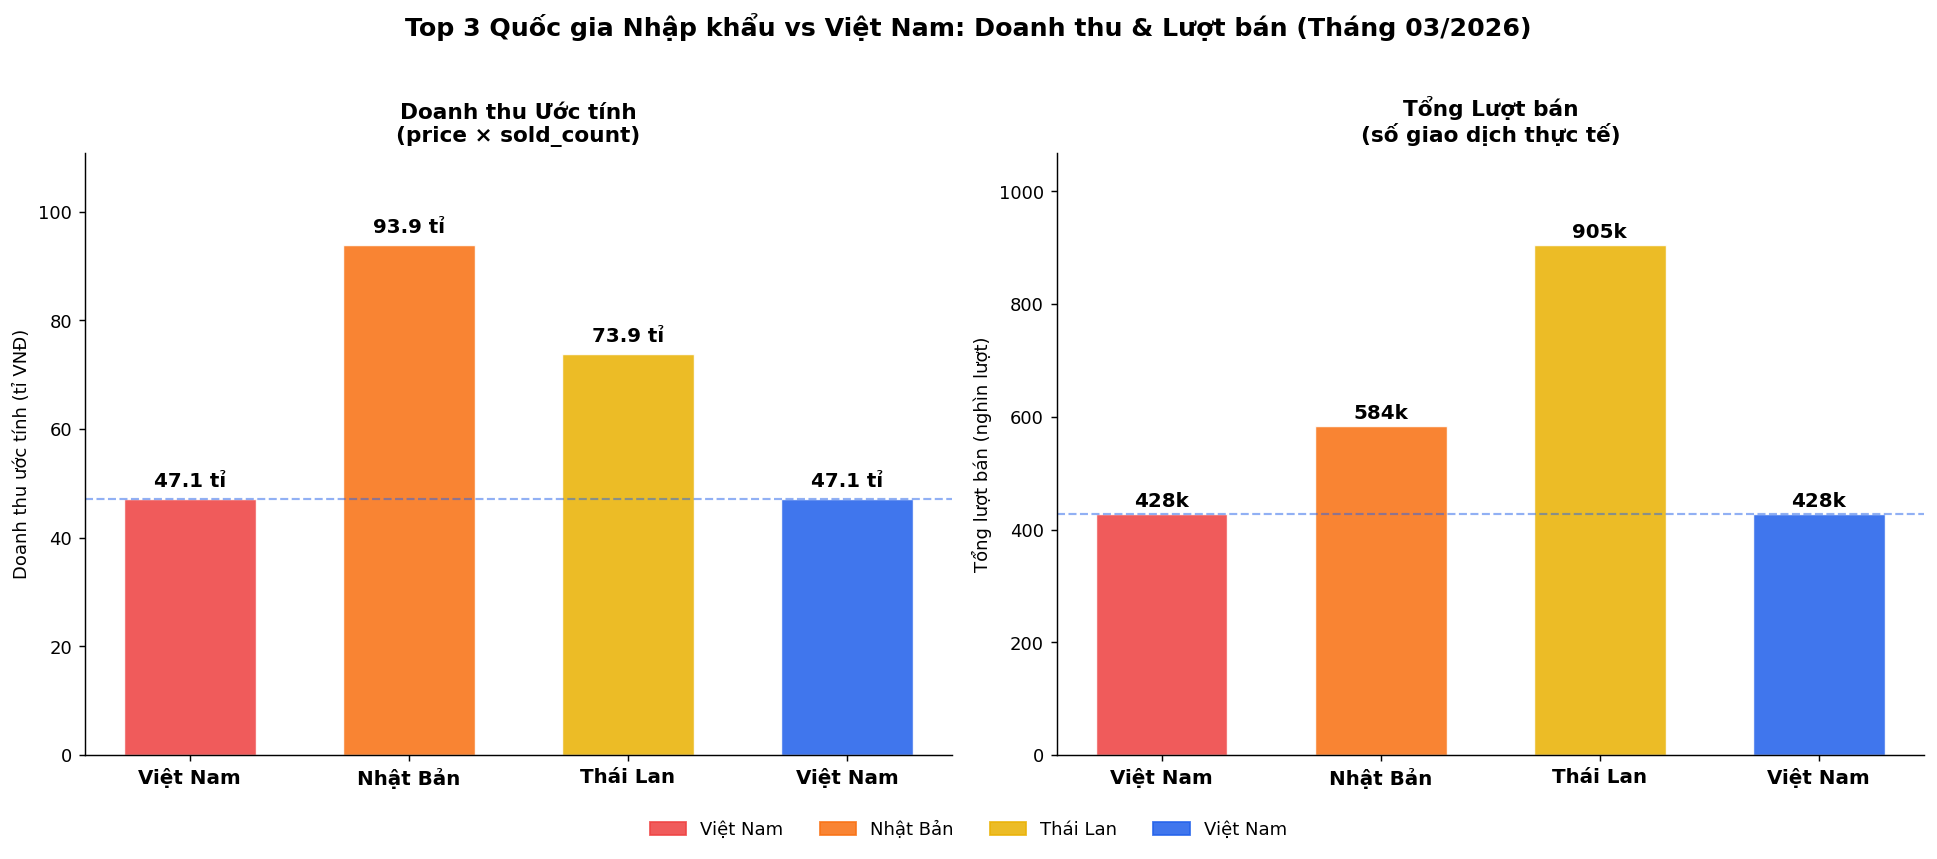

In [15]:
# 1. CHUẨN BỊ DỮ LIỆU SO SÁNH
compare_countries = TOP3 + ['Việt Nam']
bar_colors        = ['#EF4444', '#F97316', '#EAB308', '#2563EB']

# Dữ liệu từng quốc gia
rev_vals  = []
sold_vals = []
for c in compare_countries:
    if c == 'Việt Nam':
        rev_vals.append(df_vn['estimated_revenue'].sum() / 1e9)
        sold_vals.append(df_vn['sold_count'].sum() / 1000)   # nghìn lượt
    else:
        sub = df_nn[df_nn['origin_normalized'] == c]
        rev_vals.append(sub['estimated_revenue'].sum() / 1e9)
        sold_vals.append(sub['sold_count'].sum() / 1000)

# 2. VẼ BIỂU ĐỒ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 3 Quốc gia Nhập khẩu vs Việt Nam: Doanh thu & Lượt bán (Tháng 03/2026)',
             fontsize=14, fontweight='bold', y=1.02)

x     = np.arange(len(compare_countries))
width = 0.6

# ── Panel trái: Doanh thu ước tính ──────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(x, rev_vals, width=width, color=bar_colors, alpha=0.88,
                edgecolor='white', linewidth=0.8)
for bar, val in zip(bars1, rev_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             f'{val:.1f} tỉ',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_xticks(x)
ax1.set_xticklabels(compare_countries, fontsize=11, fontweight='bold')
ax1.set_ylabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax1.set_title('Doanh thu Ước tính\n(price × sold_count)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(rev_vals) * 1.18)
# Đường tham chiếu Việt Nam
ax1.axhline(y=rev_vals[-1], color='#2563EB', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Mức VN')

# ── Panel phải: Lượt bán ────────────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(x, sold_vals, width=width, color=bar_colors, alpha=0.88,
                edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, sold_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{val:,.0f}k',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_xticks(x)
ax2.set_xticklabels(compare_countries, fontsize=11, fontweight='bold')
ax2.set_ylabel('Tổng lượt bán (nghìn lượt)', fontsize=10)
ax2.set_title('Tổng Lượt bán\n(số giao dịch thực tế)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(sold_vals) * 1.18)
ax2.axhline(y=sold_vals[-1], color='#2563EB', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Mức VN')

# Chú thích màu sắc
legend_patches = [mpatches.Patch(color=c, label=l, alpha=0.88)
                  for c, l in zip(bar_colors, compare_countries)]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()


#### Dựa vào biểu đồ cột nhóm so sánh Top 3 quốc gia với Việt Nam, ta rút ra một số nhận xét sau:

- **Bất ngờ lớn nhất: Thái Lan vượt Nhật Bản về lượt bán** — 893k vs 581k lượt, trong khi Thái Lan chỉ có 190 sản phẩm so với 1.109 sản phẩm của Nhật. Toàn bộ câu chuyện Thái Lan là câu chuyện của Nivea và Nivea Men — hai thương hiệu "sản xuất tại Thái Lan" đang thống trị danh mục lăn xịt khử mùi với lượt bán khổng lồ.

- **Nhật Bản là đối thủ số 1 về doanh thu** (88 tỉ VNĐ) — gấp hơn 2 lần Pháp (9,8 tỉ) và gần 13 lần Hàn Quốc (6,8 tỉ). Điều này cho thấy hàng Nhật không chỉ bán nhiều mà còn bán ở mức giá tốt — kết hợp lý tưởng giữa khối lượng và giá trị.

- **Hàn Quốc: nhiều sản phẩm, ít doanh thu** — 31% kệ hàng nhập khẩu nhưng chỉ 6,8 tỉ doanh thu. Lý do: phần lớn hàng Hàn có sold_count rất thấp (chưa bán được nhiều). Đây là "đội quân đang ngủ" — tiềm năng lớn nhưng chưa kích hoạt được.

- **Việt Nam vượt trội cả 3 đối thủ về lượt bán** (2.765k lượt — gấp 3 lần Thái Lan) và doanh thu (260 tỉ — gấp 3 lần Nhật Bản). Đây là dấu hiệu tích cực: người tiêu dùng Việt vẫn đang "bỏ phiếu bằng ví tiền" cho hàng nội nhiều hơn.

**Kết luận:**

Phân tích cơ cấu quốc gia tiết lộ ba loại đối thủ khác nhau mà mỹ phẩm Việt Nam cần đối mặt với chiến lược riêng biệt:

| Quốc gia | Điểm mạnh | Mức độ cạnh tranh trực tiếp |
|----------|-----------|---------------------------|
| 🥇 **Nhật Bản** | Doanh thu cao nhất (88 tỉ), hệ sinh thái thương hiệu đa dạng (158 nhãn hiệu), cạnh tranh ở Skincare đại trà | ⚡ **Cao nhất** — Skincare phân khúc 100k–500k |
| 🥈 **Thái Lan** | Lượt bán cao nhất (893k), chiến lược tập trung (Nivea) rất hiệu quả ở Body Care | ⚡ **Cao** — Body Care & Khử mùi đại trà |
| 🥉 **Pháp** | Fragrance cao cấp, giá TB 1,1 triệu — phân khúc hàng nội gần như vắng mặt | ↕ **Gián tiếp** — Fragrance & Skincare cao cấp |

Hàn Quốc — dù hiện diện đông đảo nhất về số sản phẩm — chưa phải mối đe dọa cấp thiết về doanh thu, nhưng sẽ trở thành đối thủ đáng gờm khi các thương hiệu K-beauty tiếp tục đầu tư vào thị trường Việt Nam. Thương hiệu Việt nên **ưu tiên phòng thủ phân khúc 100k–500k trước làn sóng Nhật–Thái**, đồng thời **thận trọng theo dõi Hàn Quốc** như một mối nguy tiềm ẩn dài hạn.